In [1]:
from function_lib import *

In [2]:
# ----------------- config -----------------
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

In [3]:
# ---------------------------------------------------------
# Load all result files cleanly
# ---------------------------------------------------------

result_names = {
    "LST":  f"Shortest_path_LST_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl",
    "DIO":  f"Shortest_path_DIO_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl",
    "PAIR": f"Shortest_path_pair_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl",
    "MLE":  f"Shortest_path_MLE_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl",
    "SPO":  f"Shortest_path_spo_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl",
}

save_path = os.path.join(base_path, "Results", "Score")

loaded_results = {}

for key, fname in result_names.items():
    file_path = os.path.join(save_path, fname)
    with open(file_path, "rb") as f:
        loaded_results[key] = pickle.load(f)

# Merge all dictionaries (Python 3.9+)
total_result = {}
for key in loaded_results:
    total_result |= loaded_results[key]

model_list = ["DIO-0.1", "LST-0.1", "LST-1", "LST-10", "PAR-0.1", "MLE", "SPO"]

  Model   Mean   Std  VaR90 CVaR90
DIO-0.1 10.73% 5.33% 17.15% 21.39%
LST-0.1 10.46% 4.77% 16.79% 19.01%
  LST-1 10.01% 5.54% 17.35% 19.30%
 LST-10  9.43% 5.09% 16.19% 19.95%
PAR-0.1  9.78% 4.98% 16.39% 20.44%
    MLE  9.34% 5.11% 16.27% 20.11%
    SPO  9.73% 5.04% 16.56% 20.25%


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_4740\2897382493.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


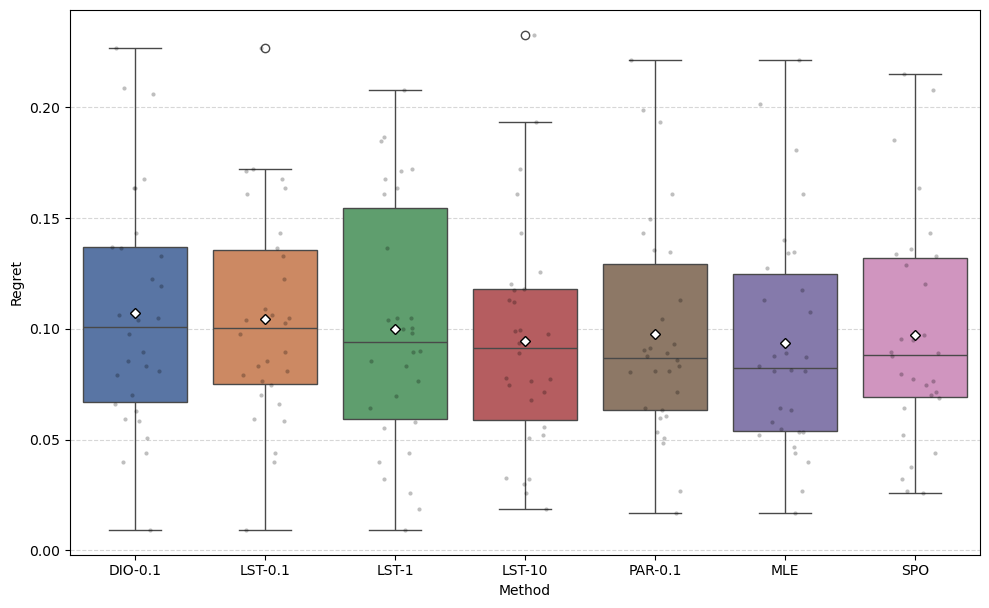

In [4]:

# rows = []
# for model_type in model_list:
#     regrets = total_result[model_type]["regret"]
#     mean, std, var90, cvar90 = compute_stats(regrets)

#     rows.append({
#         "Model": model_type,
#         "Mean": mean,
#         "Std": std,
#         "VaR90": var90,
#         "CVaR90": cvar90
#     })

# # convert to DataFrame
# df = pd.DataFrame(rows)

# # nicely formatted print
# print(df.to_string(index=False, float_format="%.6f"))
rows = []
for model_type in model_list:
    regrets = total_result[model_type]["regret"]
    mean, std, var90, cvar90 = compute_stats(regrets)

    rows.append({
        "Model": model_type,
        "Mean": mean,
        "Std": std,
        "VaR90": var90,
        "CVaR90": cvar90
    })

df = pd.DataFrame(rows)

# Convert numeric columns to percentage strings
percent_cols = ["Mean", "Std", "VaR90", "CVaR90"]
for col in percent_cols:
    df[col] = df[col].apply(lambda x: f"{x*100:.2f}%")

print(df.to_string(index=False))

# # Collect regret distributions across all model types
# df_list = []
# for model_type, data in total_result.items():
#     df_list.append(pd.DataFrame({
#         "method": [model_type] * len(data["regret"]),
#         "regret": data["regret"]
#     }))

df_list = []
for model_type in model_list:
    if model_type in total_result:
        data = total_result[model_type]
        df_list.append(pd.DataFrame({
            "method": [model_type] * len(data["regret"]),
            "regret": data["regret"]
        }))

df = pd.concat(df_list, ignore_index=True)

# Academic color palette
palette = sns.color_palette("deep")
unique_methods = sorted(df["method"].unique())
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(unique_methods)}

plt.figure(figsize=figure_size(10))

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

# plt.title("Regret Distribution Across Methods", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "percentage_regret_comparison.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()